In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="darkgrid")

In [13]:
import os
import pandas as pd
import numpy as np

os.chdir(r"C:\Users\pc\climate-challenge-week0")

df = pd.read_csv("data/sudan.csv", sep="\t")
df["Country"] = "sudan"

# Replace NASA sentinel values
df.replace(-999, np.nan, inplace=True)

# Parse date
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,sudan,2015-01-05,1


In [14]:
# Duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# Summary stats
df.describe()

Duplicate rows: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


In [15]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({"Missing": missing, "Percent": missing_pct})
print(missing_report[missing_report["Percent"] > 0])

Empty DataFrame
Columns: [Missing, Percent]
Index: []


In [16]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(stats.zscore, nan_policy="omit")
outliers = (z_scores.abs() > 3)
print("Outlier counts per column:")
print(outliers.sum())

Outlier counts per column:
T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64


In [17]:
# Forward fill weather variables
df[cols] = df[cols].ffill()

# Export cleaned data
df.to_csv("data/sudan_clean.csv", index=False)
print("Cleaned data exported.")

Cleaned data exported.


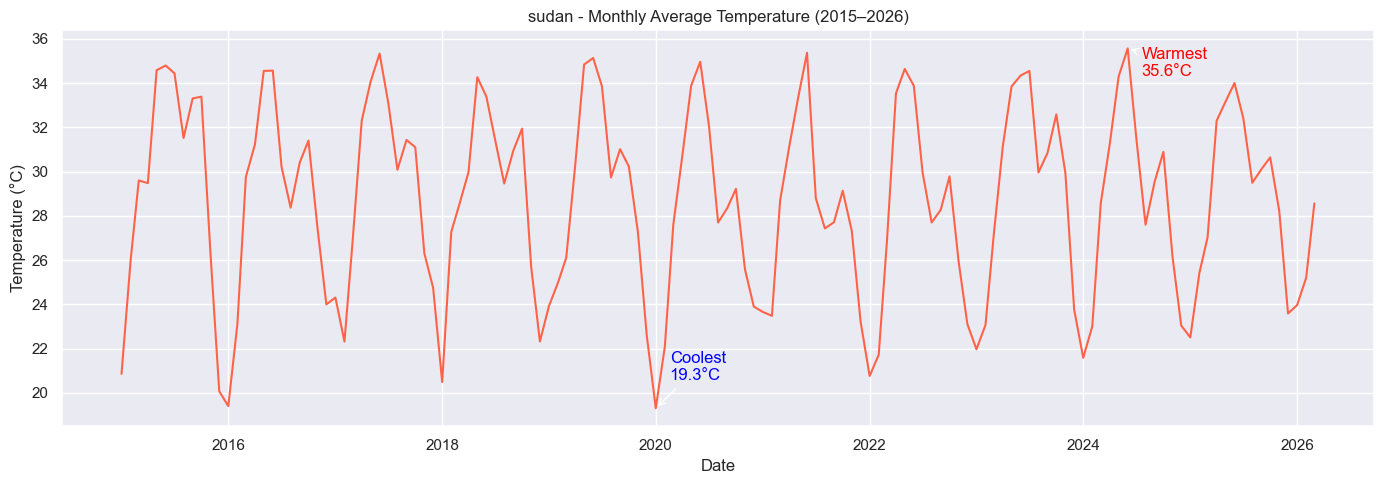

In [18]:
monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(monthly_temp[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp["Date"], monthly_temp["T2M"], color="tomato")

# Annotate warmest and coolest
warmest = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
coolest = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

plt.annotate(f'Warmest\n{warmest["T2M"]:.1f}°C', 
             xy=(warmest["Date"], warmest["T2M"]),
             xytext=(10, -20), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"), color="red")

plt.annotate(f'Coolest\n{coolest["T2M"]:.1f}°C', 
             xy=(coolest["Date"], coolest["T2M"]),
             xytext=(10, 20), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"), color="blue")

plt.title("sudan - Monthly Average Temperature (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.savefig("notebooks/sudan_temp_trend.png")
plt.show()

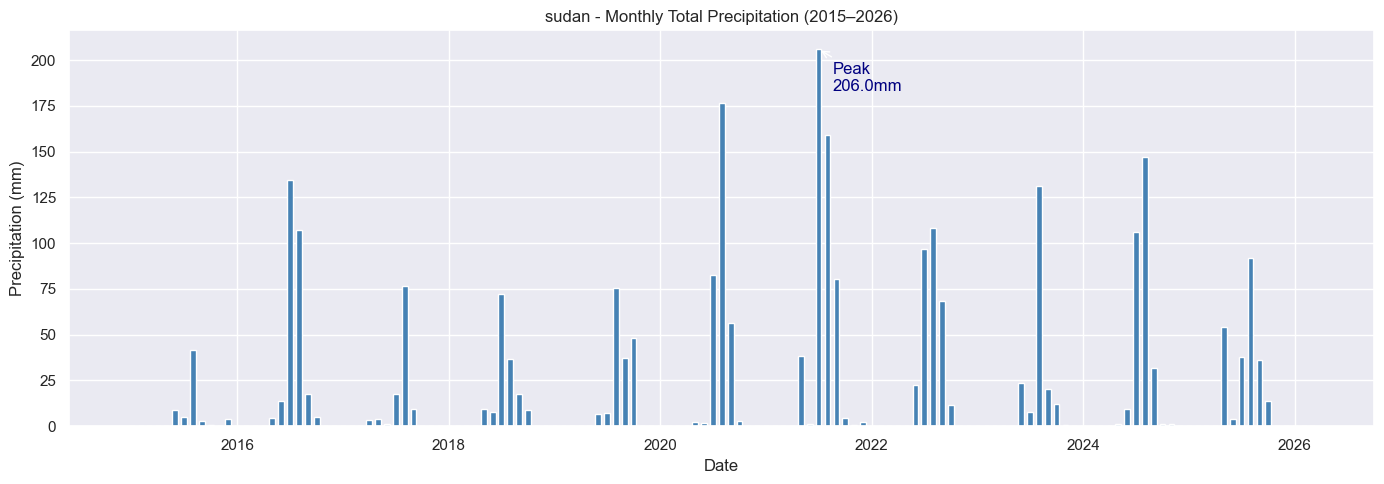

In [19]:
monthly_precip = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
monthly_precip["Date"] = pd.to_datetime(monthly_precip[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.bar(monthly_precip["Date"], monthly_precip["PRECTOTCORR"], color="steelblue", width=20)

peak = monthly_precip.loc[monthly_precip["PRECTOTCORR"].idxmax()]
plt.annotate(f'Peak\n{peak["PRECTOTCORR"]:.1f}mm',
             xy=(peak["Date"], peak["PRECTOTCORR"]),
             xytext=(10, -30), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"), color="navy")

plt.title("sudan - Monthly Total Precipitation (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")
plt.tight_layout()
plt.savefig("notebooks/sudan_precip.png")
plt.show()

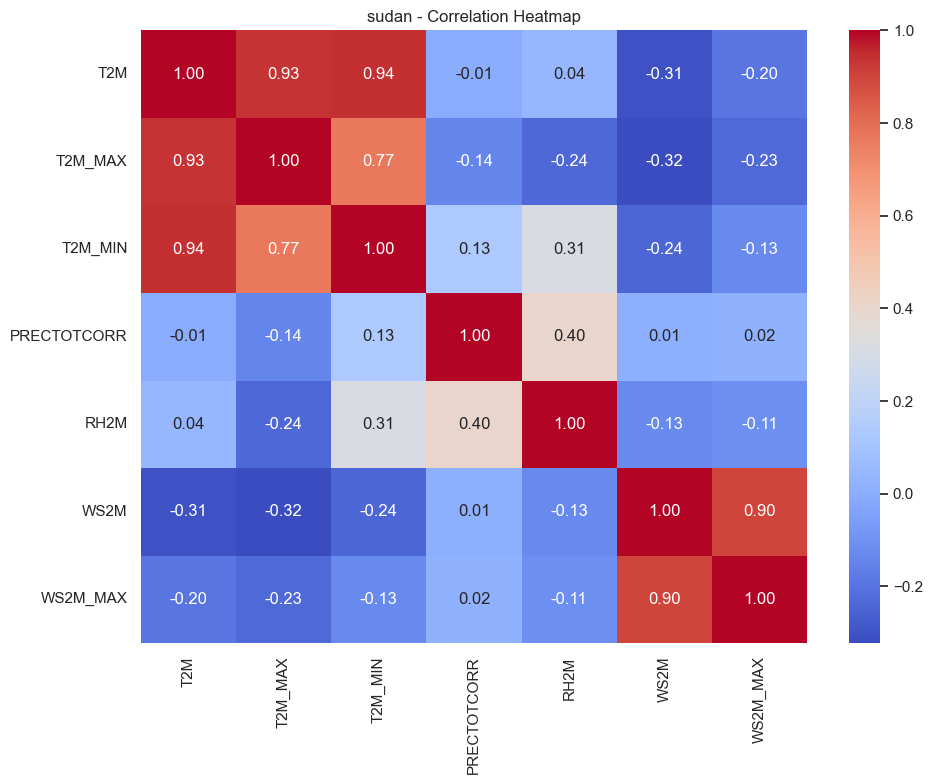

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("sudan - Correlation Heatmap")
plt.tight_layout()
plt.savefig("notebooks/sudan_corr.png")
plt.show()

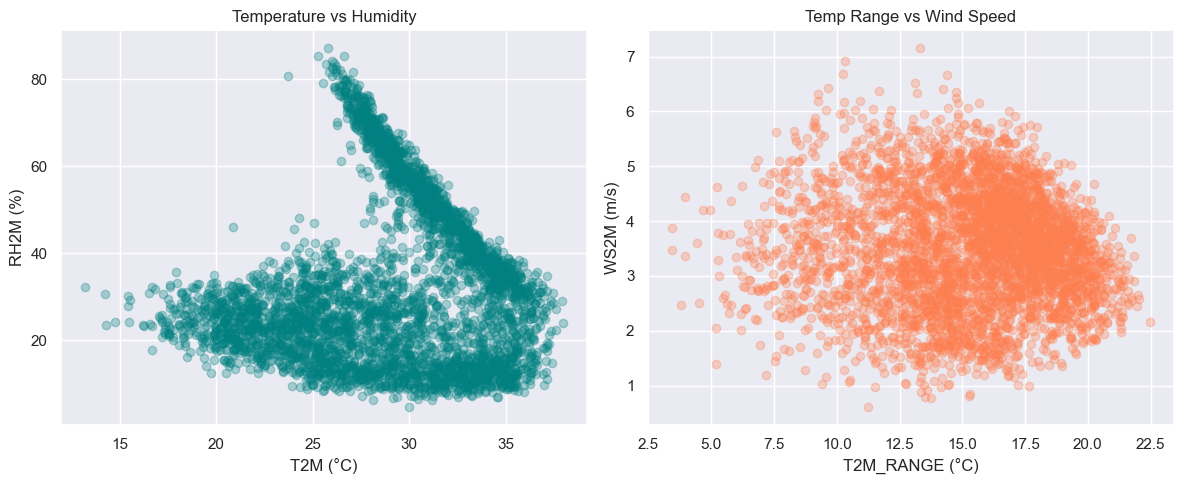

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df["T2M"], df["RH2M"], alpha=0.3, color="teal")
axes[0].set_xlabel("T2M (°C)")
axes[0].set_ylabel("RH2M (%)")
axes[0].set_title("Temperature vs Humidity")

axes[1].scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.3, color="coral")
axes[1].set_xlabel("T2M_RANGE (°C)")
axes[1].set_ylabel("WS2M (m/s)")
axes[1].set_title("Temp Range vs Wind Speed")

plt.tight_layout()
plt.savefig("notebooks/sudan_scatter.png")
plt.show()

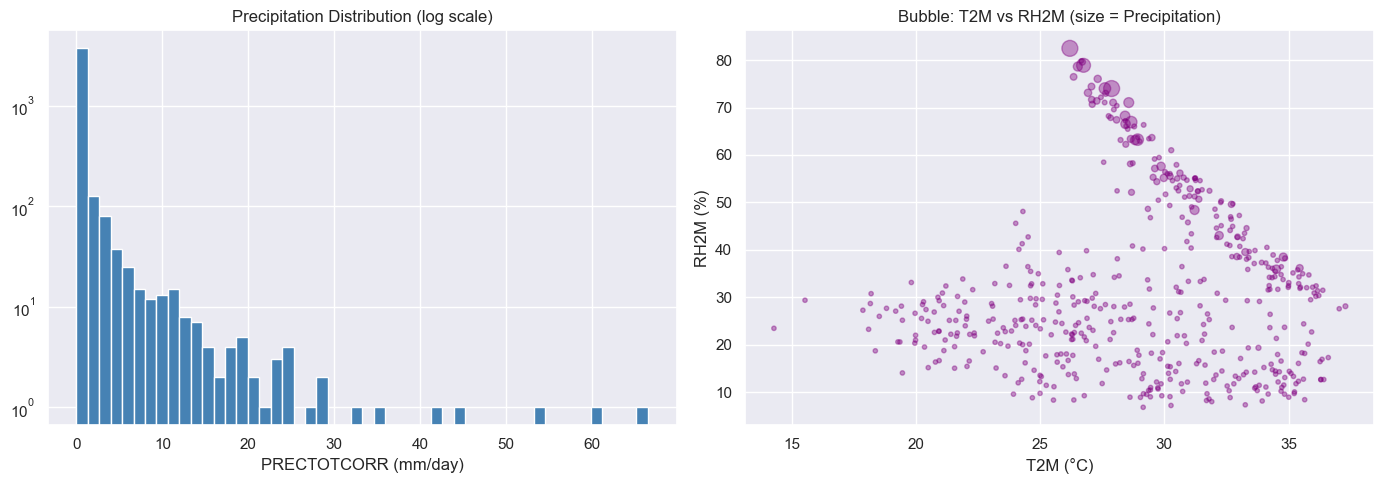

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with log scale
axes[0].hist(df["PRECTOTCORR"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Precipitation Distribution (log scale)")
axes[0].set_xlabel("PRECTOTCORR (mm/day)")

# Bubble chart
sample = df.sample(500, random_state=42)
axes[1].scatter(sample["T2M"], sample["RH2M"],
                s=sample["PRECTOTCORR"].fillna(0) * 5 + 10,
                alpha=0.4, color="purple")
axes[1].set_xlabel("T2M (°C)")
axes[1].set_ylabel("RH2M (%)")
axes[1].set_title("Bubble: T2M vs RH2M (size = Precipitation)")

plt.tight_layout()
plt.savefig("notebooks/sudan_dist.png")
plt.show()